## DBSCAN

In [1]:
import mglearn
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import DBSCAN

### example

In [2]:
X_train, _ = make_blobs(random_state=0, n_samples=12)
print("X_train.shape:", X_train.shape)

X_train.shape: (12, 2)


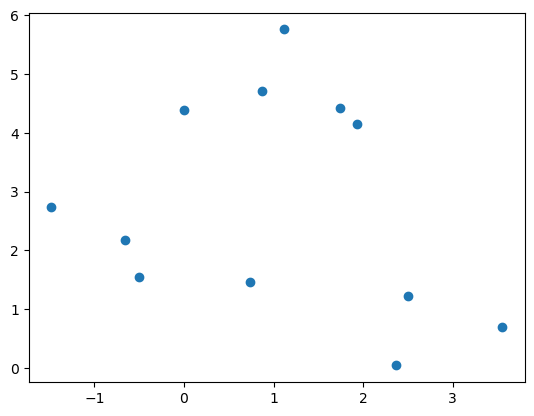

In [3]:
plt.scatter(X_train[:,0], X_train[:,1])

In [4]:
dbscan = DBSCAN()
dbscan.fit(X_train)

DBSCAN()

In [5]:
assignments_X_train = dbscan.labels_
print(assignments_X_train)

[-1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1]


#### all samples become noisy samples

min_samples: 2 eps: 1.000000  cluster: [-1  0  0 -1  0 -1  1  1  0  1 -1 -1]
min_samples: 2 eps: 1.500000  cluster: [0 1 1 1 1 0 2 2 1 2 2 0]
min_samples: 2 eps: 2.000000  cluster: [0 1 1 1 1 0 0 0 1 0 0 0]
min_samples: 2 eps: 3.000000  cluster: [0 0 0 0 0 0 0 0 0 0 0 0]
min_samples: 3 eps: 1.000000  cluster: [-1  0  0 -1  0 -1  1  1  0  1 -1 -1]
min_samples: 3 eps: 1.500000  cluster: [0 1 1 1 1 0 2 2 1 2 2 0]
min_samples: 3 eps: 2.000000  cluster: [0 1 1 1 1 0 0 0 1 0 0 0]
min_samples: 3 eps: 3.000000  cluster: [0 0 0 0 0 0 0 0 0 0 0 0]
min_samples: 5 eps: 1.000000  cluster: [-1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1]
min_samples: 5 eps: 1.500000  cluster: [-1  0  0  0  0 -1 -1 -1  0 -1 -1 -1]
min_samples: 5 eps: 2.000000  cluster: [-1  0  0  0  0 -1 -1 -1  0 -1 -1 -1]
min_samples: 5 eps: 3.000000  cluster: [0 0 0 0 0 0 0 0 0 0 0 0]


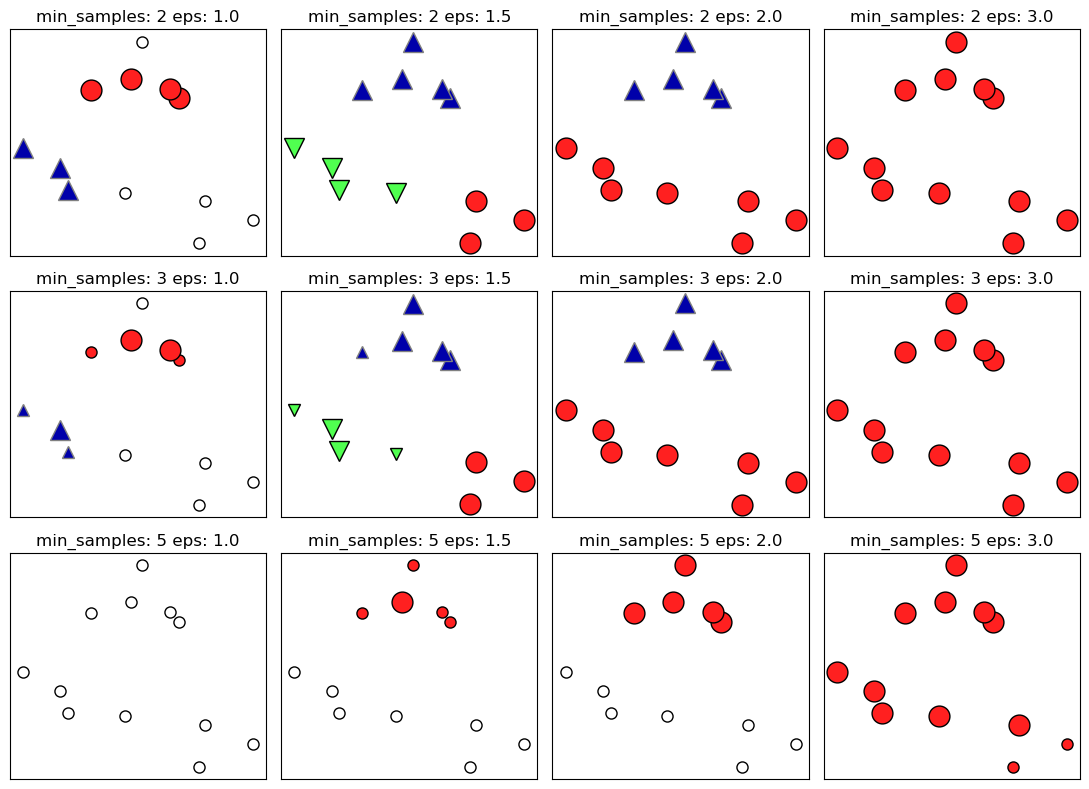

In [6]:
mglearn.plots.plot_dbscan()

### example with scaling

In [7]:
from sklearn.datasets import make_blobs
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import MinMaxScaler

X_train, _ = make_blobs(random_state=0, n_samples=12)
print("X_train.shape:", X_train.shape)

X_train.shape: (12, 2)


In [8]:
scaler = MinMaxScaler((-1,1))
X_train_scaled = scaler.fit_transform(X_train)

In [9]:
dbscan = DBSCAN()
dbscan.fit(X_train_scaled)

DBSCAN()

In [10]:
assignments_X_train = dbscan.labels_
print(assignments_X_train)

[-1  0  0  0  0 -1 -1 -1  0 -1 -1 -1]


## Clustering Evaluation (K-Means)

In [11]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [12]:
X, _ = make_blobs(
    n_samples=500,
    n_features=2,
    centers=4,
    cluster_std=1,
    center_box=(-10.0, 10.0),
    shuffle=True,
    random_state=1,
) 

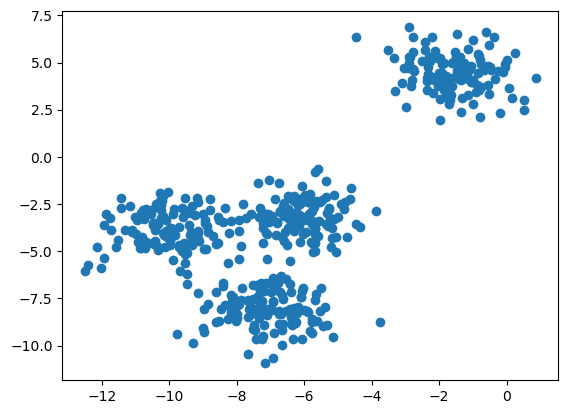

In [13]:
plt.scatter(X[:,0], X[:,1])

In [14]:
inertia = []
sil_scores = []

for n_clusters in range(2,10):
    kmeans = KMeans(n_clusters=n_clusters, random_state=10)
    cluster_labels = kmeans.fit_predict(X)
    
    inertia.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X, cluster_labels))
    

C:\Users\oms83\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\oms83\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\oms83\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\oms83\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environme

In [15]:
inertia

[3735.4056749295632,
 1903.5607664611762,
 908.3855684760613,
 817.4470680159146,
 727.2600975739831,
 647.5238195990781,
 577.4713083206149,
 521.4112580528634]

In [16]:
sil_scores

[0.7049787496083262,
 0.5882004012129721,
 0.6505186632729437,
 0.56376469026194,
 0.4504666294372765,
 0.39092211029930857,
 0.33148538996489124,
 0.3349898818697859]

#### elbow method (heuristic)

Text(0.5, 1.0, 'K-Means Inertia')

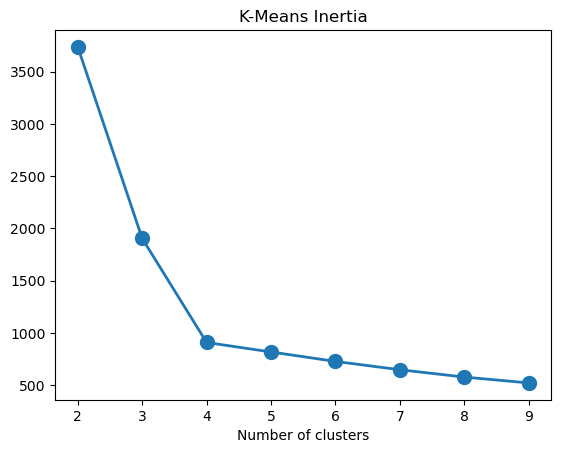

In [17]:
plt.plot(range(2,10), inertia, marker='o', lw=2, ms=10)
plt.xlabel("Number of clusters")
plt.title("K-Means Inertia")

In [18]:
sil_scores

[0.7049787496083262,
 0.5882004012129721,
 0.6505186632729437,
 0.56376469026194,
 0.4504666294372765,
 0.39092211029930857,
 0.33148538996489124,
 0.3349898818697859]

Text(0.5, 1.0, 'Silhouette Score')

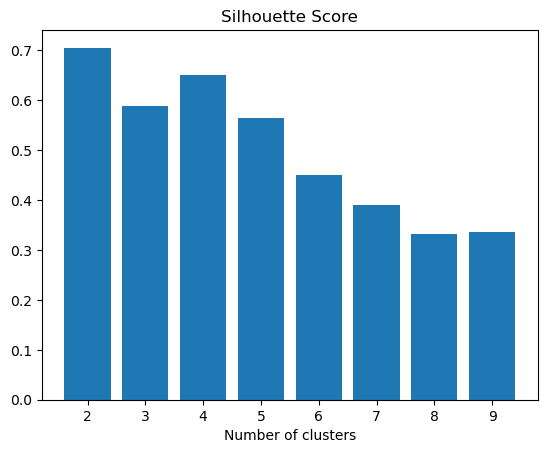

In [19]:
plt.bar(range(2,10), sil_scores, )
plt.xlabel("Number of clusters")
plt.title("Silhouette Score")